Aperçu du dataset :
   Unnamed: 0       job_title   job_type experience_level       location  \
0           0  Data scientist  Full Time           Senior  New York City   
1           2  Data scientist  Full Time           Senior         Boston   
2           3  Data scientist  Full Time           Senior         London   
3           4  Data scientist  Full Time           Senior         Boston   
4           5  Data scientist  Full Time           Senior  New York City   

  salary_currency  salary  
0             USD  149000  
1             USD  120000  
2             USD   68000  
3             USD  120000  
4             USD  149000  

Extrait avec salaire normalisé :
   salary  salary_normalized
0  149000           0.601010
1  120000           0.454545
2   68000           0.191919
3  120000           0.454545
4  149000           0.601010
Colonnes disponibles dans le fichier :
Index(['Unnamed: 0', 'job_title', 'job_type', 'experience_level', 'location',
       'salary_currency', 'sal

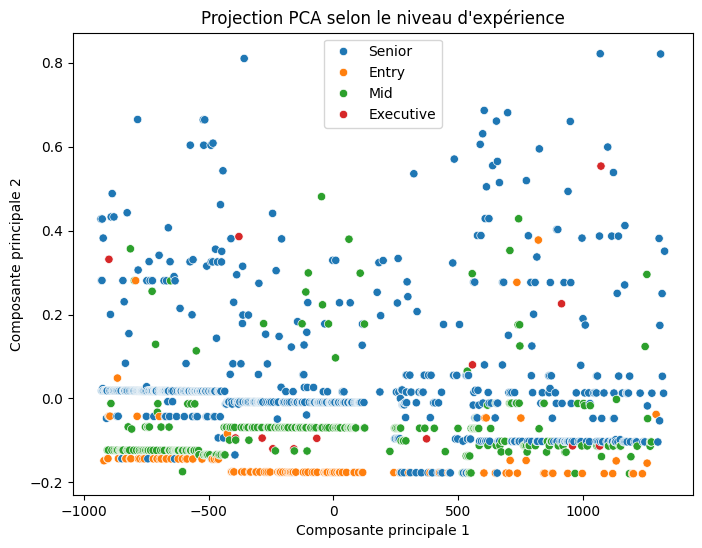


Salaires moyens et médians par niveau d'expérience :
  experience_level          mean   median
0            Entry  36111.111111  30000.0
1        Executive  76076.923077  46000.0
2              Mid  51786.885246  51000.0
3           Senior  75088.033012  68000.0


In [7]:
#Daily challenge : Data Handling and Analysis in Python
 # Étape 1 : Importation des bibliothèques
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Étape 2 : Chargement du dataset
# Assurez-vous que le fichier 'ds_salaries.csv' est dans le même répertoire
df = pd.read_csv("/content/datascience_salaries.csv")

# Affichage des premières lignes pour comprendre la structure
print("Aperçu du dataset :")
print(df.head())

# Étape 3 : Normalisation de la colonne 'salary_in_usd'
scaler = MinMaxScaler()
df['salary_normalized'] = scaler.fit_transform(df[['salary']])

print("\nExtrait avec salaire normalisé :")
print(df[['salary', 'salary_normalized']].head())
print("Colonnes disponibles dans le fichier :")
print(df.columns)

# Étape 4 : Réduction de dimension avec PCA
# On sélectionne uniquement les colonnes numériques pour le PCA
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['salary']).copy()

# PCA pour réduire à 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(numeric_cols)

# Ajout des résultats PCA au dataframe
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# Affichage graphique
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='experience_level', data=df)
plt.title('Projection PCA selon le niveau d\'expérience')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend()
plt.show()

# Étape 5 : Agrégation des salaires par niveau d'expérience
agg_salary = df.groupby('experience_level')['salary'].agg(['mean', 'median']).reset_index()

print("\nSalaires moyens et médians par niveau d'expérience :")
print(agg_salary)